In [82]:
import time

start = time.time()

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
import statsmodels.api as sm

end = time.time()

print(f"Import time: {str(end - start)}")

Import time: 0.00013208389282226562


## Задание 1

In [83]:
days = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница']
street = np.array([80, 98, 75, 91, 78])
garage = np.array([100, 82, 105, 89, 102])

r, p_value = stats.pearsonr(street, garage)

print(f"Коэффициент корреляции Пирсона r = {r:.4f}")

Коэффициент корреляции Пирсона r = -1.0000


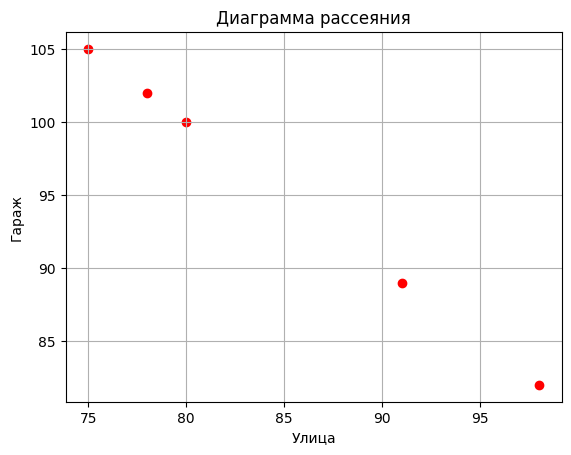

In [84]:
days = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница']
street = np.array([80, 98, 75, 91, 78])
garage = np.array([100, 82, 105, 89, 102])

plt.scatter(street, garage, color='r')
plt.title('Диаграмма рассеяния')
plt.xlabel('Улица')
plt.ylabel('Гараж')
plt.grid(True)
plt.show()

## Задание 2

## Задание 3

In [85]:
df = pd.read_csv('PR4/insurance.csv')

print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация по колонкам:")
print(df.info())

regions = df['region'].unique()
print("\nУникальные регионы:", regions)

print("\nПропуски по колонкам:")
print(df.isna().sum())


Первые 5 строк:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Информация по колонкам:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Уникальные регионы: ['southwest' 'southeast' 'no

In [86]:
groups = [df.loc[df['region'] == r, 'bmi'].values for r in regions]
f_stat, p_val = stats.f_oneway(*groups)
print("\nОднофакторный ANOVA (scipy) по region -> BMI:")
print(f"F = {f_stat:.4f}, p-value = {p_val:.6f}")


Однофакторный ANOVA (scipy) по region -> BMI:
F = 39.4951, p-value = 0.000000


In [87]:
model = ols('bmi ~ C(region)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)  # тип II
print("\nANOVA (statsmodels) по region -> BMI:")
print(anova_table)


ANOVA (statsmodels) по region -> BMI:
                 sum_sq      df          F        PR(>F)
C(region)   4055.880631     3.0  39.495057  1.881839e-24
Residual   45664.319755  1334.0        NaN           NaN


In [88]:
pairs = list(combinations(regions, 2))
p_values = []
results = []

for a, b in pairs:
    group_a = df.loc[df['region'] == a, 'bmi']
    group_b = df.loc[df['region'] == b, 'bmi']
    t_stat, p = stats.ttest_ind(group_a, group_b, equal_var=False)
    p_values.append(p)
    results.append((a, b, t_stat, p))

rej, pvals_corr, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
print("\nПопарные т-тесты (Welch) с поправкой Бонферрони:")
for i, (a, b, t_stat, p) in enumerate(results):
    print(f"{a} vs {b}: t={t_stat:.4f}, p={p:.6f}, p_bonf={pvals_corr[i]:.6f}, reject={rej[i]}")


Попарные т-тесты (Welch) с поправкой Бонферрони:
southwest vs southeast: t=-5.9516, p=0.000000, p_bonf=0.000000, reject=True
southwest vs northwest: t=3.2844, p=0.001078, p_bonf=0.006465, reject=True
southwest vs northeast: t=3.1167, p=0.001910, p_bonf=0.011460, reject=True
southeast vs northwest: t=9.3768, p=0.000000, p_bonf=0.000000, reject=True
southeast vs northeast: t=8.8355, p=0.000000, p_bonf=0.000000, reject=True
northwest vs northeast: t=0.0603, p=0.951940, p_bonf=1.000000, reject=False



Результаты Тьюки:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
northeast northwest   0.0263 0.9999 -1.1552  1.2078  False
northeast southeast   4.1825    0.0   3.033   5.332   True
northeast southwest   1.4231 0.0107  0.2416  2.6046   True
northwest southeast   4.1562    0.0  3.0077  5.3047   True
northwest southwest   1.3968 0.0127  0.2162  2.5774   True
southeast southwest  -2.7594    0.0 -3.9079 -1.6108   True
----------------------------------------------------------


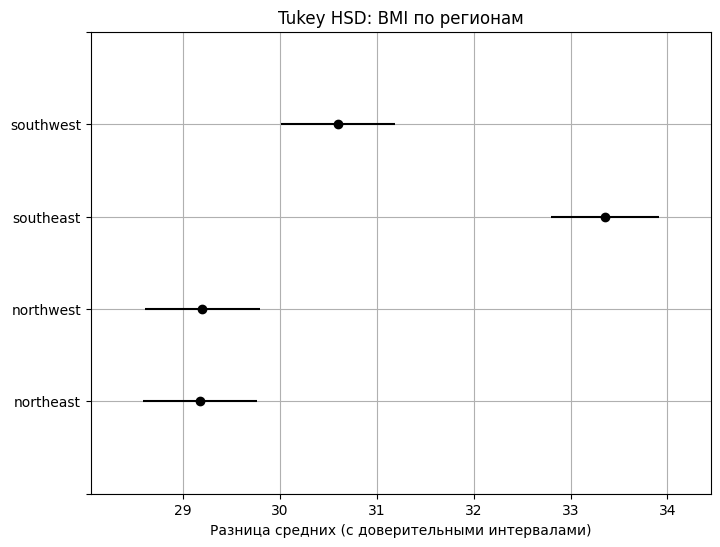

In [108]:
tukey = pairwise_tukeyhsd(endog=df['bmi'], groups=df['region'], alpha=0.05)
print("\nРезультаты Тьюки:")
print(tukey.summary())

fig = tukey.plot_simultaneous(figsize=(8,6))
plt.title("Tukey HSD: BMI по регионам")
plt.xlabel("Разница средних (с доверительными интервалами)")
plt.grid(True)
plt.show()

In [100]:
model2 = ols('bmi ~ C(region) + C(sex) + C(region):C(sex)', data=df).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)
print("\nДвухфакторный ANOVA (region, sex, region:sex):")
print(anova_table2)


Двухфакторный ANOVA (region, sex, region:sex):
                        sum_sq      df          F        PR(>F)
C(region)          4034.975135     3.0  39.398134  2.163195e-24
C(sex)               86.007035     1.0   2.519359  1.126940e-01
C(region):C(sex)    174.157808     3.0   1.700504  1.650655e-01
Residual          45404.154911  1330.0        NaN           NaN



Tukey для sex:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
female   male   0.5654  0.09 -0.0883 1.2191  False
--------------------------------------------------


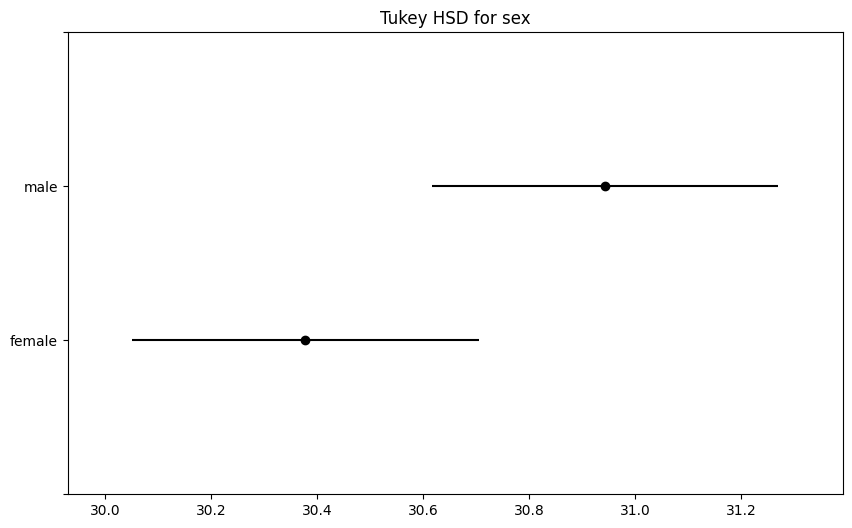

In [106]:
tukey_sex = pairwise_tukeyhsd(endog=df['bmi'], groups=df['sex'], alpha=0.05)
print("\nTukey для sex:")
print(tukey_sex.summary())
tukey_sex.plot_simultaneous()
plt.title("Tukey HSD for sex")
plt.show()